# AA200 – Problem Set 5, Problem 2
## Elliptical Wing — Lifting-Line Theory

**Given:** AR = 5, $m_0 = 5.7$ /rad, $V = 45$ m/s, $W/S = 1000$ N/m², $b = 10$ m, sea level ($\rho = 1.225$ kg/m³), level flight ($L=W$).

---
## 1. Sectional and Lift Coefficients

In level flight $L = W$, so:

$$C_L = \frac{W/S}{\tfrac{1}{2}\rho V^2} = \frac{1000}{\tfrac{1}{2}\times 1.225 \times 45^2}=c_\ell(y) \quad \text{(elliptic wing)}$$

In [1]:
import numpy as np

AR = 5; m0 = 5.7; V = 45.0; WoS = 1000.0; rho = 1.225; b = 10.0
S = b**2 / AR

CL = WoS / (0.5 * rho * V**2)
print(f'S  = {S:.2f} m²')
print(f'CL = cl = {CL:.4f}')

S  = 20.00 m²
CL = cl = 0.8062


---
## 2. Sectional and Total Drag Coefficients
$$ (Total) C_{D_i} = \frac{C_L^2}{\pi AR}= c_{d_i} (Sectional)$$

In [2]:
CDi = CL**2 / (np.pi * AR)
print(f'C_Di = c_di = {CDi:.4f}')

C_Di = c_di = 0.0414


## 3. Angles of Attack

For an elliptically loaded wing, the induced angle of attack is constant along the span.

We first define the **signed induced angle**

$$
\alpha_i^{\,\text{signed}} = -\frac{C_L}{\pi AR}
$$

Since downwash tilts the local flow downward, the induced angle is negative.

The sectional lift coefficient is related to the **effective angle of attack** by

$$
c_\ell = c_{\ell_\alpha}(\alpha_{\text{eff}} - \alpha_{L=0})
$$

For a symmetric airfoil ($\alpha_{L=0}=0$):

$$
\alpha_{\text{eff}} = \frac{c_\ell}{c_{\ell_\alpha}}
$$

The geometric (absolute) angle of attack must include the **magnitude of the induced angle**

$$
\alpha_0 = \alpha_{\text{eff}} + |\alpha_i^{\,\text{signed}}|
$$

which can also be written as

$$
\alpha_0 = \frac{c_\ell}{c_{\ell_\alpha}} - \alpha_i^{\,\text{signed}}
$$

In [7]:
ai_rad = -CL / (np.pi * AR)
a0_rad = CL / m0 - ai_rad   # with alpha_L0 = 0

print(f'alpha_i = {np.degrees(ai_rad):.4f} deg  ({ai_rad:.4f} rad)')
print(f'alpha_0 = {np.degrees(a0_rad):.4f} deg  ({a0_rad:.4f} rad)')

alpha_i = -2.9408 deg  (-0.0513 rad)
alpha_0 = 11.0452 deg  (0.1928 rad)


---
## 4. Spanwise Plot

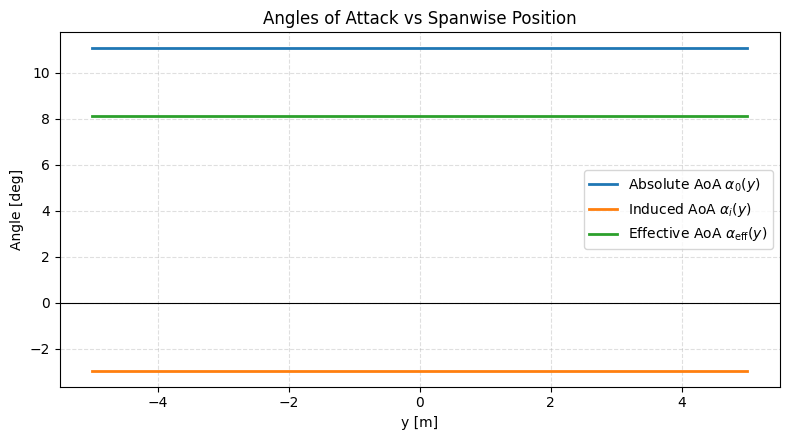

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Spanwise coordinate
y = np.linspace(-b/2, b/2, 500)

# Constant distributions for an elliptically loaded untwisted wing
alpha_i_dist   = np.full_like(y, np.degrees(ai_rad))
alpha_0_dist   = np.full_like(y, np.degrees(a0_rad))
alpha_eff_dist = alpha_0_dist + alpha_i_dist

# Plot
plt.figure(figsize=(8,4.5))

plt.plot(y, alpha_0_dist, lw=2, label=r'Absolute AoA $\alpha_0(y)$')
plt.plot(y, alpha_i_dist, lw=2, label=r'Induced AoA $\alpha_i(y)$')
plt.plot(y, alpha_eff_dist, lw=2, label=r'Effective AoA $\alpha_{\mathrm{eff}}(y)$')

plt.axhline(0, color='k', lw=0.8)

plt.xlabel('y [m]')
plt.ylabel('Angle [deg]')
plt.title('Angles of Attack vs Spanwise Position')

plt.grid(True, ls='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

---
## 5. Power Required to Overcome Induced Drag

$$P = D_i \cdot V = \tfrac{1}{2}\rho V^2 S \cdot C_{D_i} \cdot V$$

In [ ]:
Di = 0.5 * rho * V**2 * S * CDi
Power = Di * V

print(f'Induced drag  Di = {Di:.2f} N')
print(f'Power required P = {Power:.1f} W  ({Power/1000:.2f} kW)')

Induced drag  Di = 1026.55 N
Power required P = 46194.6 W  (46.19 kW)


---
## Recap

| Quantity | Value |
|---|---|
| $S$ | 20.00 m² |
| $C_L$ | 0.806 |
| $c_{\ell_\alpha}=m_0$ | 5.7 rad⁻¹ |
| $C_{L_\alpha}$ | 4.18 rad⁻¹ |
| $C_{D_i}$ | 0.0414 |
| $\alpha_i$ | −2.94° (constant spanwise) |
| $\alpha_{\text{eff}}$ | 8.10° (constant spanwise) |
| $\alpha_0$ | 11.04° (constant spanwise) |
| $D_i$ | 1026.6 N |
| Power | 46.19 kW |